In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.chdir("..")

from dirdet.config.physics import GALACTIC, NeutrinoRegistry
from dirdet.config.targets import XENON, FLUORINE

from dirdet.wimp_rates import dRdE_WIMP, dRdEdO_WIMP
from dirdet.neutrino_rates import dRdE_CEvNS, dRdEdO_CEvNS
from dirdet.nuclear_phyics import form_factor_helm

from dirdet.neutrino_fog import MakeDL, Floor_2D


In [2]:
# define directions
x_sun = np.array([1,0,0])
x_lab = np.array([0,1,0])

# recoil vectos
resol: int = 8 # xpix resolution
q_raw = np.loadtxt(f"input_data/xpix/xpix{resol}.txt",unpack=False)
forward, backward = (q_raw[:,2] > 0, q_raw[:,2] < 0)

# angle for neutrino recoil
costheta_sun_arr = np.dot(q_raw, x_sun)
# del_omega
n_pix = len(q_raw)
del_omega = 4.0*np.pi/n_pix 
# lab vel
v_lab = x_lab * GALACTIC.V_LAB

# energy
E_r = np.geomspace(1e-3,1e3,1000)

# wimp params
m_chi_arr = np.geomspace(1e-1,1e4,100)
sigma_p = 1e-45

# neutrino params
neutrinos = NeutrinoRegistry.all_sources()
nu_uncert = np.loadtxt('input_data/neutrino_fluxes/Nu_flux_uncert',unpack=True)[1] 
flux_path: str = "input_data/neutrino_fluxes"

# Non Directional Neutrino Fog

To generate the neutrino fog in high resolution requires lots of calculations, forcing a long processing time. Specifically these calcualtions are done by the `MakeDL` function. 

For this reason, the calculated results have been saved as an array under `nu_fog_data`, with the parameters for high resolution defined as `n_ex=2000` and `ns=1000`. If you wish to perform these calculations yourself, but dont want to wait too long, I would reccomend chanign the parameters under this section to:
- `n_ex=200`
- `ns=100`
Then in the plot section, comment out the lines that load the functions, and run the plot cell. This should give you a low resolution of the fog, which you can then compare with the high resolution.

## Calculate

In [3]:
#------------ cumtrapz ------------#

R_wimp = np.zeros((len(m_chi_arr), len(E_r)-1))
R_nu = np.zeros((len(neutrinos), len(E_r)-1))

# wimp event
for i, m in enumerate(m_chi_arr):
    dR = dRdE_WIMP(E_r,m,sigma_p,XENON.A)
    R_wimp[i, :] = 0.5 * np.diff(E_r) * (dR[:-1] + dR[1:])

# neutrino event 
for i, nu in enumerate(neutrinos):
    E_nu, Flux = nu.get_nu_energy_and_flux(path=flux_path)
    dR = dRdE_CEvNS(E_r,E_nu,Flux,XENON.A,XENON.Z)
    R_nu[i,:] = 0.5 * np.diff(E_r) * (dR[:-1] + dR[1:])# Precision parameters


#------------ Neutrino Fog Calc ------------#
# change these (if calculating):
n_ex = 200
ns = 100

# don't change, unless u know what ur doing
Ex_min = 1.0e-6 # ton-years
Ex_max = 1.0e20 # ton-years
sigma_min = 1e-50 # cm^2
sigma_max = 1e-43 # cm^2

# Generate neutrino fog
m_vals,sig_vals,DL = MakeDL(
    m_vals = m_chi_arr,
    R_sig = R_wimp,
    R_nu = R_nu,
    NuUnc = nu_uncert,
    sigma_ref = sigma_p,
    sigma_min = sigma_min,
    sigma_max = sigma_max,
    ns = ns,
    Ex_min= Ex_min,
    Ex_max = Ex_max,
    n_ex= n_ex
)


100%|██████████| 100/100 [00:12<00:00,  7.75it/s]


## Plotting

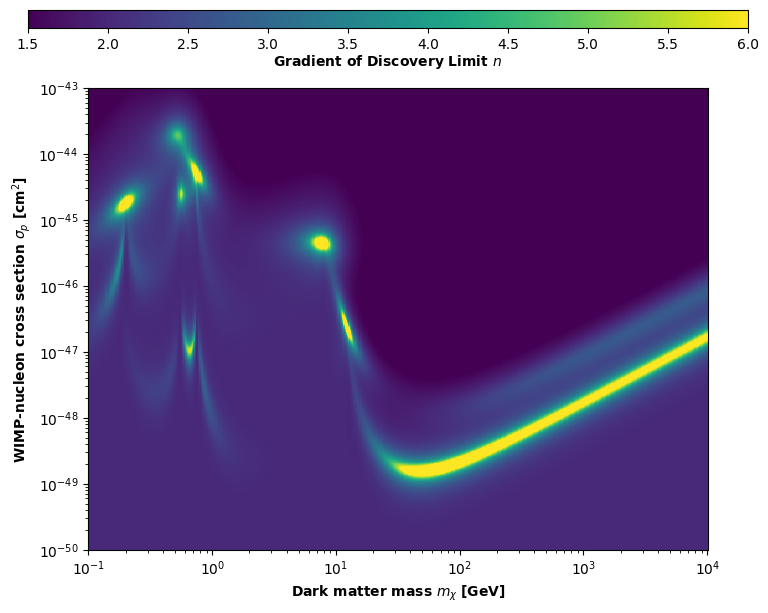

In [ ]:
dir = "nu_fog_data"

# load data, comment these out if using calculated value
m_vals = np.loadtxt(f"{dir}/ND_m_vals(n_ex_2000_ns_1000).txt")
sig_vals = np.loadtxt(f"{dir}//ND_sig_vals(n_ex_2000_ns_1000).txt")
DL = np.loadtxt(f"{dir}//ND_DL(n_ex_2000_ns_1000).txt")

NUFLOOR,NUFOG = Floor_2D(m_vals,sig_vals,DL,filt=False)

# plot
plt.figure(figsize=(8, 6))
plt.pcolormesh(m_vals,sig_vals,NUFOG,vmin=1.5,vmax=6)

plt.yscale('log')
plt.xscale('log')
plt.ylabel('WIMP-nucleon cross section $\\sigma_p$ [cm$^2$]',fontweight="bold")
plt.xlabel('Dark matter mass $m_\\chi$ [GeV]',fontweight="bold")

# Create a separate axis for the color bar
cbar_ax = plt.axes([0.05, 0.98, 0.9, 0.03])  # [left, bottom, width, height]
cbar = plt.colorbar(cax=cbar_ax, orientation='horizontal')
cbar.set_label('Gradient of Discovery Limit $n$', labelpad=1,fontweight="bold")



# Directional Fog 

## Calculation 

Same thing as above, long calculation time, so precalculated array used. But can run this code with smaller parameters, to get plot with lower resolution.

In [ ]:
## define energy bins
num_bins = 100
edges = np.geomspace(E_r.min(), E_r.max(), num_bins + 1)

# initalise recoil
R_wimp = np.zeros((len(m_chi_arr), num_bins * np.sum(forward)))
R_nu   = np.zeros((len(neutrinos), num_bins * np.sum(forward)))
FF = form_factor_helm(E_r=edges, A=FLUORINE.A)

# Directional WIMP Event Rate
for i,m in enumerate(m_chi_arr):

    # non dir calc, required for normalisation
    dR = dRdE_WIMP(
        E_r=E_r,
        m_chi=m,sigma_p=sigma_p,
        A=FLUORINE.A)
    R_nd = 0.5 * np.diff(E_r) * (dR[:-1] + dR[1:])

    # dir calc
    dR_mat = dRdEdO_WIMP(
        E_r=edges, x_pix=q_raw, 
        m_chi=m, sigma_p=sigma_p, 
        A=FLUORINE.A, v_lab=v_lab)
    
    # fold the recoil
    dR_mat = dR_mat[backward] + dR_mat[forward]

    # cumtrapz
    R_mat = 0.5 * np.diff(edges) * (dR_mat[:, :-1] + dR_mat[:, 1:]) * del_omega

    # normalisation 
    R_norm = R_mat * (np.sum(R_nd)/np.sum(R_mat))
    R_wimp[i,:] = R_norm.flatten()

# Directional Neutrino Event Rate
for i,nu in enumerate(neutrinos):
    # load flux and energy
    E_nu, Flux = nu.get_nu_energy_and_flux(path=flux_path)

    # non dir calc
    dR = dRdE_CEvNS(E_r=E_r, E_nu=E_nu, Flux=Flux, A=FLUORINE.A, Z=FLUORINE.Z)
    R_nd = 0.5 * np.diff(E_r) * (dR[:-1] + dR[1:])

    # dir calc
    dR_mat = dRdEdO_CEvNS(
        neutrino=nu, E_nu=E_nu, Flux=Flux,
        E_r=edges, cosThetaSun_arr=costheta_sun_arr, FF=FF)
    
    # fold the recoil
    dR_mat = dR_mat[backward] + dR_mat[forward]

    # cumtrapz
    R_mat = 0.5 * np.diff(edges) * (dR_mat[:, :-1] + dR_mat[:, 1:]) * del_omega
    
    # normalisation 
    R_norm = R_mat * (np.sum(R_nd)/np.sum(R_mat))
    R_nu[i,:] = R_norm.flatten()

#------------ Neutrino Fog Calc ------------#
# change these (if calculating):
n_ex = 200
ns = 100

# don't change, unless u know what ur doing
Ex_min = 1.0e-6 # ton-years
Ex_max = 1.0e20 # ton-years
sigma_min = 1e-50 # cm^2
sigma_max = 1e-43 # cm^2

# Generate neutrino fog
m_vals,sig_vals,DL = MakeDL(
    m_vals = m_chi_arr,
    R_sig = R_wimp,
    R_nu = R_nu,
    NuUnc = nu_uncert,
    sigma_ref = sigma_p,
    sigma_min = sigma_min,
    sigma_max = sigma_max,
    ns = ns,
    Ex_min= Ex_min,
    Ex_max = Ex_max,
    n_ex= n_ex
)

## Plotting

### Directional Neutrino Fog

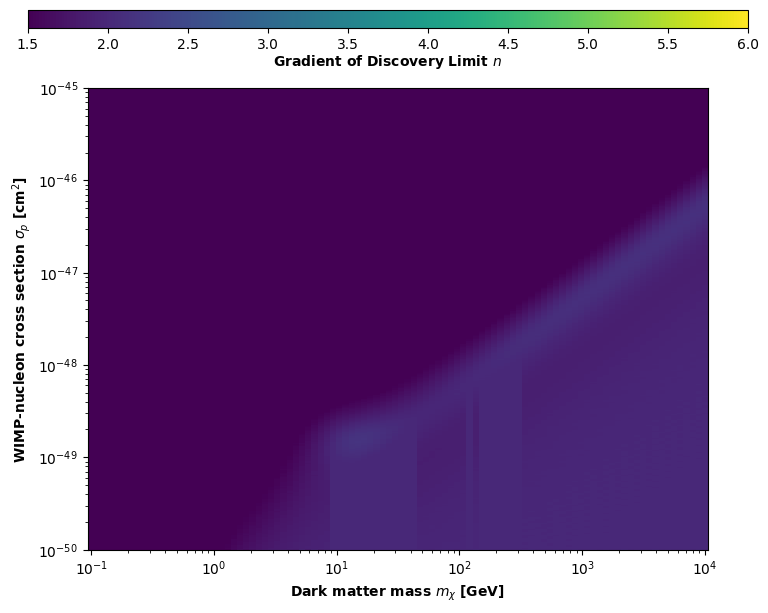

In [ ]:
dir = "nu_fog_data"
# load data, comment these out if using calculated value
m_vals = np.loadtxt(f"{dir}/m_vals(n_ex_1400_ns_1000).txt")
sig_vals = np.loadtxt(f"{dir}//sig_vals(n_ex_1400_ns_1000).txt")
DL = np.loadtxt(f"{dir}//DL(n_ex_1400_ns_1000).txt")

NUFLOOR,NUFOG = Floor_2D(m_vals,sig_vals,DL,filt=False)

# plot
plt.figure(figsize=(8, 6))
plt.pcolormesh(m_vals,sig_vals,NUFOG,vmin=1.5,vmax=6)

plt.yscale('log')
plt.xscale('log')
plt.ylabel('WIMP-nucleon cross section $\\sigma_p$ [cm$^2$]',fontweight="bold")
plt.xlabel('Dark matter mass $m_\\chi$ [GeV]',fontweight="bold")

# Create a separate axis for the color bar
cbar_ax = plt.axes([0.05, 0.98, 0.9, 0.03])  # [left, bottom, width, height]
cbar = plt.colorbar(cax=cbar_ax, orientation='horizontal')
cbar.set_label('Gradient of Discovery Limit $n$', labelpad=1,fontweight="bold")


### Non-Directional and Directional Neutrino Fog Comparison

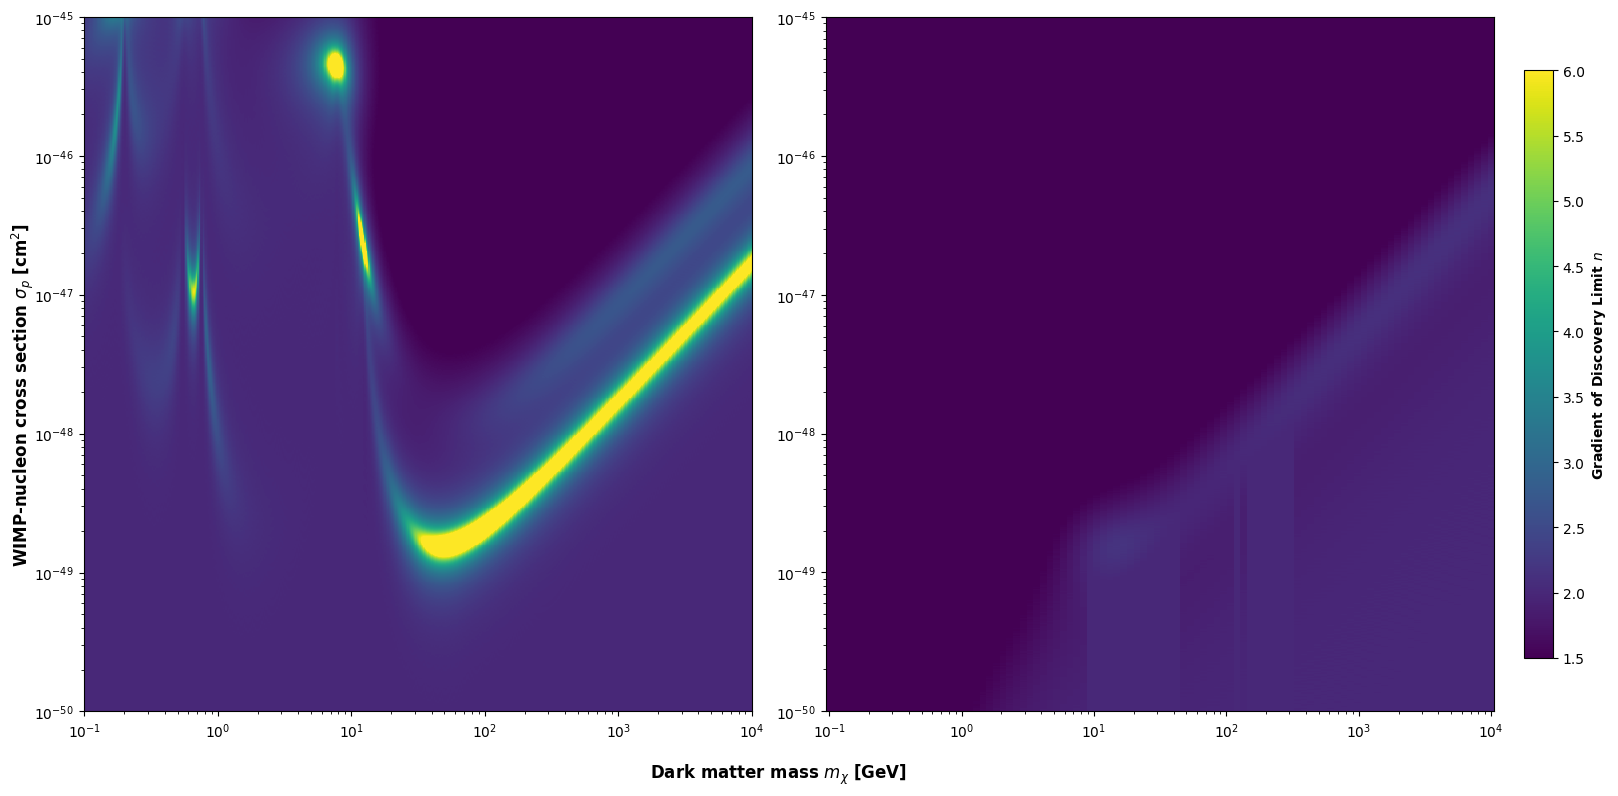

In [64]:
fig, (ax_left, ax_right) = plt.subplots(1,2,figsize=(16,8))

fig.supxlabel('Dark matter mass $m_\\chi$ [GeV]',fontweight="bold")
fig.supylabel('WIMP-nucleon cross section $\\sigma_p$ [cm$^2$]',fontweight="bold")
dir = "nu_fog_data"

# Non-Dir Nu Fog (left_ax)
m_vals = np.loadtxt(f"{dir}/ND_m_vals(n_ex_2000_ns_1000).txt")
sig_vals = np.loadtxt(f"{dir}//ND_sig_vals(n_ex_2000_ns_1000).txt")
DL = np.loadtxt(f"{dir}//ND_DL(n_ex_2000_ns_1000).txt")
NUFLOOR,NUFOG = Floor_2D(m_vals,sig_vals,DL,filt=False)
im = ax_left.pcolormesh(m_vals,sig_vals,NUFOG,vmin=1.5,vmax=6)
ax_left.set_yscale('log')
ax_left.set_xscale('log')
ax_left.set_ylim(1e-50, 1e-45)

# Dir Nu Fog (right_ax)
m_vals = np.loadtxt(f"{dir}/m_vals(n_ex_1400_ns_1000).txt")
sig_vals = np.loadtxt(f"{dir}//sig_vals(n_ex_1400_ns_1000).txt")
DL = np.loadtxt(f"{dir}//DL(n_ex_1400_ns_1000).txt")
NUFLOOR,NUFOG = Floor_2D(m_vals,sig_vals,DL,filt=False)

ax_right.pcolormesh(m_vals,sig_vals,NUFOG,vmin=1.5,vmax=6)
ax_right.set_yscale('log')
ax_right.set_xscale('log')

plt.tight_layout()
# colour bar
cbar = fig.colorbar(im, ax=[ax_left, ax_right], orientation='vertical', location='right',pad=0.02, fraction=0.02)

cbar.set_label('Gradient of Discovery Limit $n$', fontweight="bold")

